<a href="https://colab.research.google.com/github/naotarokkwjwj/soccer/blob/main/%E5%B9%B3%E5%9D%87%E3%81%99%E3%82%8B%E5%89%8D%E3%81%AE%E3%83%87%E3%83%BC%E3%82%BF%E4%BA%AC%E9%83%BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 1. 分析したいチーム名をここで指定してください
# ------------------------------------------------------------------
target_team_name ="京都サンガF.C."  # ← ここを '川崎フロンターレ' や 'アルビレックス新潟' などに変更可能

# ------------------------------------------------------------------
# 2. データ準備 (play.csv読み込み & トラッキングデータ擬似生成)
# ------------------------------------------------------------------
try:
    # play.csv 読み込み
    raw_play = pd.read_csv('play.csv', encoding='utf-8-sig')

    # 列名変更 (日本語対応)
    col_map = {
        'チーム名': 'Team', 'アクション名': 'Action',
        '攻撃履歴No': 'AttackID', 'ボールＸ': 'x', 'ボールＹ': 'y',
        'ハーフ開始相対時間': 'Time', '履歴No': 'HistoryNo', '攻撃方向': 'Dir',
        '選手名': 'Player'
    }
    df = raw_play.rename(columns={k: v for k, v in col_map.items() if k in raw_play.columns})

    # 座標変換 & Frame生成
    df['x_m'] = pd.to_numeric(df['x'], errors='coerce') / 3.0
    df['y_m'] = pd.to_numeric(df['y'], errors='coerce') / 3.0
    time_col = df.get('Time', df.get('HistoryNo'))
    df['Frame'] = (time_col * 25 + 100000).astype(int)

    # トラッキングデータ(擬似)生成
    target_frames = df['Frame'].unique()
    track_records = []
    # ※本来は本物のトラッキングデータを使いますが、ここではデモ用に生成します
    for f in target_frames:
        for i in range(1, 12):
            track_records.append({'Frame': f, 'No': i, 'X': np.random.randint(-4000, 4000), 'Y': np.random.randint(-3000, 3000)})
    df_track = pd.DataFrame(track_records)

    # ------------------------------------------------------------------
    # 3. 個別分析ロジック実行
    # ------------------------------------------------------------------
    print(f"\n【分析対象チーム: {target_team_name}】\n")

    # チーム絞り込み
    team_df = df[df['Team'] == target_team_name].copy()
    if team_df.empty:
        print("エラー: 指定されたチームのデータが見つかりません。")
    else:
        # シュートイベント抽出
        shots = team_df[team_df['Action'].str.contains('シュート|ゴール', na=False)]
        print(f"分析対象シュート数: {len(shots)} シーン\n")

        print("-" * 90)
        print(f"{'AttackID':<10} | {'Shooter':<12} | {'Order':<6} | {'Passer':<12} | {'Type':<10} | {'V_Pack':<6} | {'D_Out':<6}")
        print("-" * 90)

        # 各シュートについてループ
        for idx, shot in shots.iterrows():
            attack_id = shot['AttackID']
            sequence = team_df[team_df['AttackID'] == attack_id].sort_values('Frame')
            try:
                shot_seq_idx = sequence.index.get_loc(idx)
            except: continue

            # シュートシーンごとのデータを格納するリスト
            scene_passes = []
            pass_count = 0

            # 遡ってパスを解析
            for i in range(1, 20):
                if shot_seq_idx - i < 0: break
                if pass_count >= 5: break

                event = sequence.iloc[shot_seq_idx - i]

                if 'パス' in str(event['Action']) or 'クロス' in str(event['Action']):
                    pass_count += 1

                    # パッキング計算
                    start_x = event['x_m']
                    next_event = sequence.iloc[shot_seq_idx - i + 1]
                    end_x = next_event['x_m']
                    if pd.isna(end_x): continue
                    if event['Dir'] == 2: start_x, end_x = -start_x, -end_x

                    frame = event['Frame']
                    opponents = df_track[df_track['Frame'] == frame]
                    opp_x = opponents['X'] / 100.0

                    v_packed = 0
                    if end_x > start_x:
                        v_packed = opponents[(opp_x > start_x) & (opp_x < end_x)].shape[0]
                    d_outplayed = opponents[opp_x < end_x].shape[0]

                    dx = end_x - start_x
                    dy = abs(next_event['y_m'] - event['y_m'])
                    p_type = 'Vertical' if (dx > 5 and dx > dy) else ('Horizontal' if (dy > dx and dy > 5) else 'Link-up')

                    # 結果をリストに追加
                    scene_passes.append({
                        'Order': -pass_count,
                        'Passer': event['Player'],
                        'Type': p_type,
                        'V_Pack': v_packed,
                        'D_Out': d_outplayed
                    })

            # 順番を整えて表示 (-5 -> -1)
            for p in sorted(scene_passes, key=lambda x: x['Order']):
                # パスの種類を日本語化して見やすく
                type_str = "縦パス" if p['Type'] == 'Vertical' else ("横パス" if p['Type'] == 'Horizontal' else "繋ぎ")

                print(f"{attack_id:<10} | {str(shot['Player']):<12} | {p['Order']:<6} | {str(p['Passer']):<12} | {type_str:<10} | {p['V_Pack']:<6} | {p['D_Out']:<6}")

            # シーンごとの区切り線
            if len(scene_passes) > 0:
                print("-" * 90)

except Exception as e:
    print(f"エラーが発生しました: {e}")


【分析対象チーム: 京都サンガF.C.】

分析対象シュート数: 13 シーン

------------------------------------------------------------------------------------------
AttackID   | Shooter      | Order  | Passer       | Type       | V_Pack | D_Out 
------------------------------------------------------------------------------------------
25         | 福岡　慎平        | -3     | 川崎　颯太        | 繋ぎ         | 0      | 10    
25         | 福岡　慎平        | -2     | 福岡　慎平        | 横パス        | 0      | 9     
25         | 福岡　慎平        | -1     | 川崎　颯太        | 横パス        | 0      | 11    
------------------------------------------------------------------------------------------
73         | 福田　心之助       | -5     | 宮本　優太        | 縦パス        | 1      | 5     
73         | 福田　心之助       | -4     | 福田　心之助       | 横パス        | 0      | 3     
73         | 福田　心之助       | -3     | 平戸　太貴        | 繋ぎ         | 0      | 4     
73         | 福田　心之助       | -2     | 宮本　優太        | 縦パス        | 4      | 6     
73         | 福田　心之助       | -1     | 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 54.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


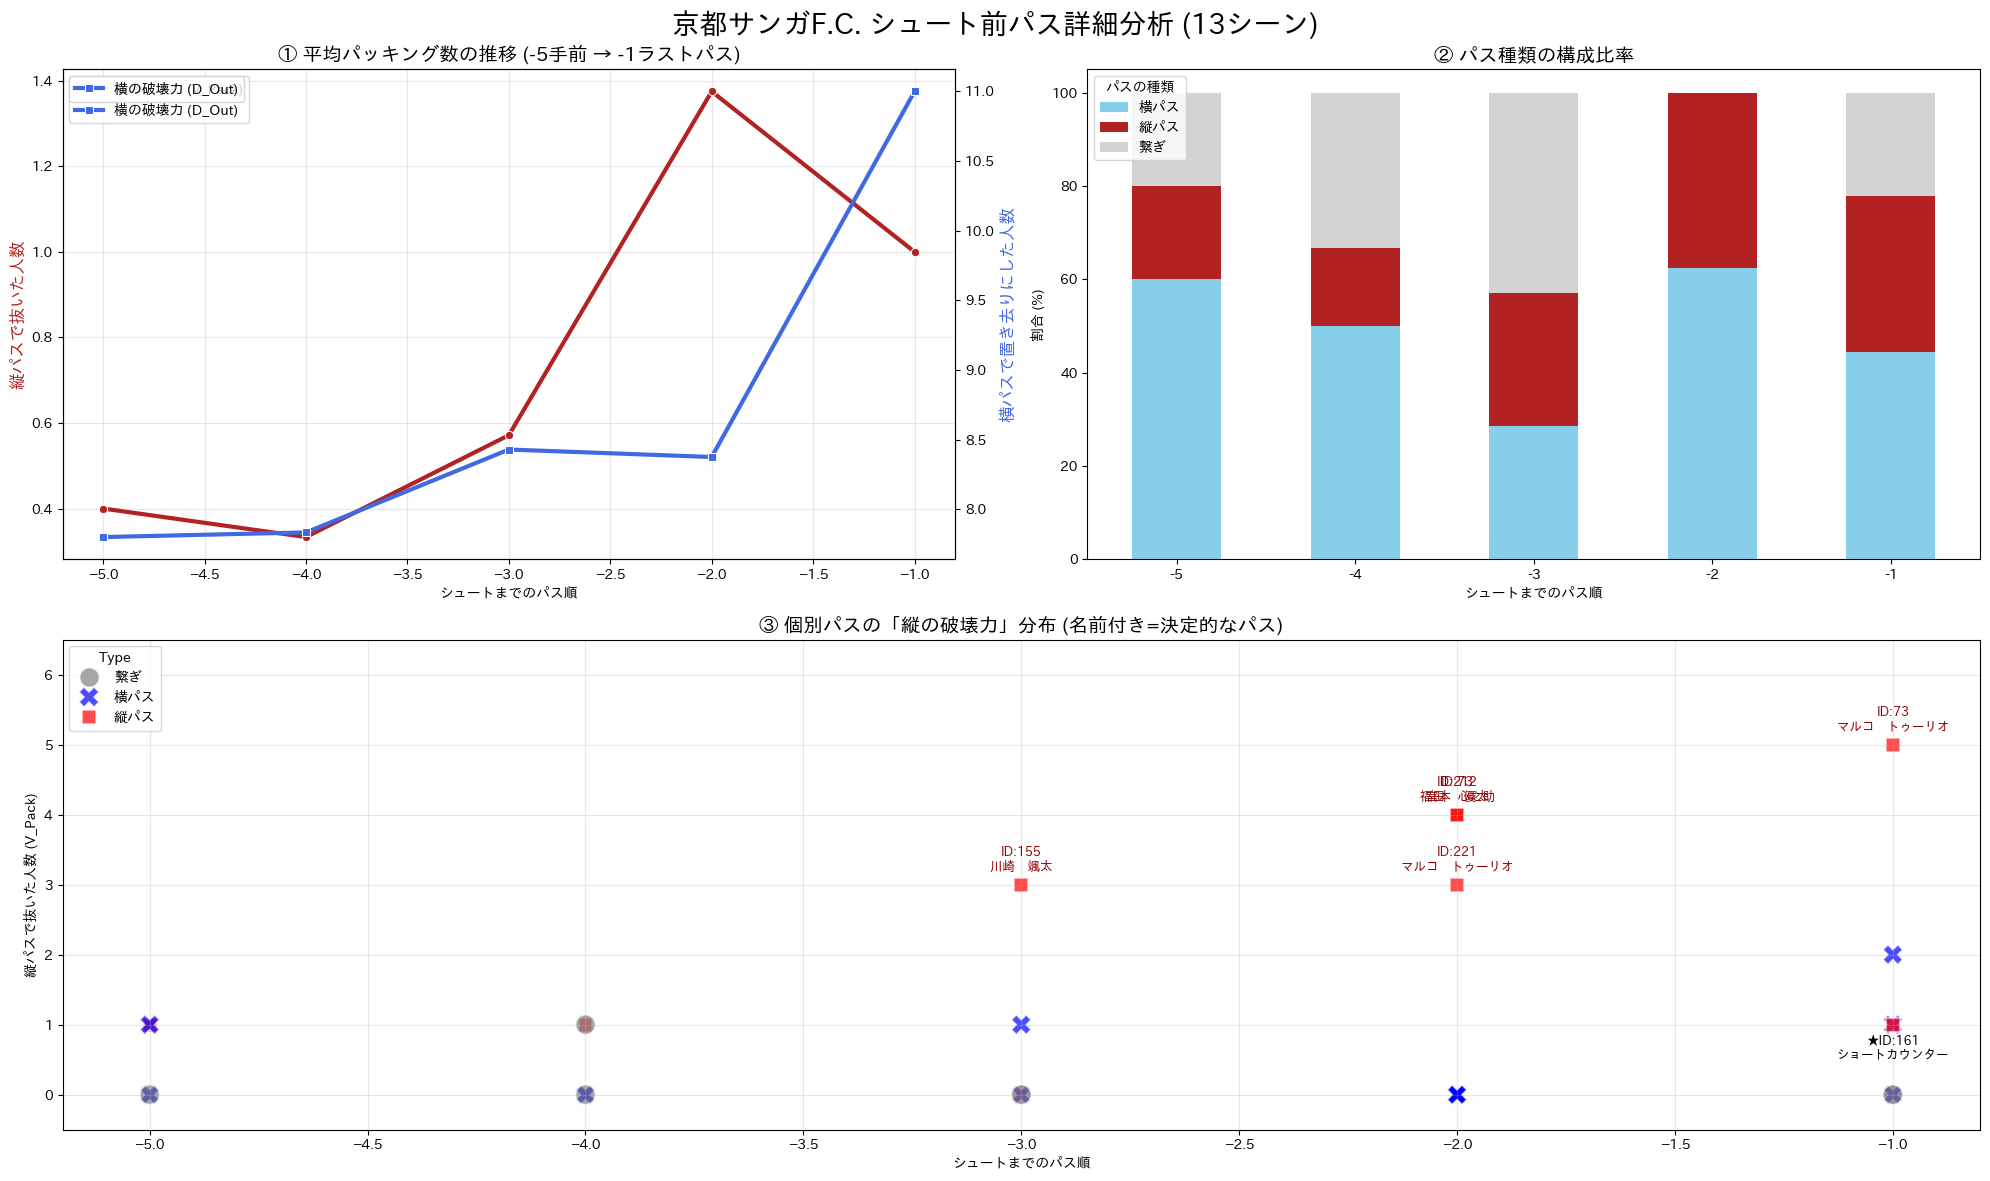

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# 日本語フォント設定
!pip install -q japanize-matplotlib
import japanize_matplotlib

# --------------------------------------------------
# 1. データの読み込み（提示されたテキストデータを直接変換）
# --------------------------------------------------
csv_data = """
AttackID|Shooter|Order|Passer|Type|V_Pack|D_Out
25|福岡　慎平|-3|川崎　颯太|繋ぎ|0|10
25|福岡　慎平|-2|福岡　慎平|横パス|0|9
25|福岡　慎平|-1|川崎　颯太|横パス|0|11
73|福田　心之助|-5|宮本　優太|縦パス|1|5
73|福田　心之助|-4|福田　心之助|横パス|0|3
73|福田　心之助|-3|平戸　太貴|繋ぎ|0|4
73|福田　心之助|-2|宮本　優太|縦パス|4|6
73|福田　心之助|-1|マルコ　トゥーリオ|縦パス|5|11
86|マルコ　トゥーリオ|-5|平戸　太貴|横パス|0|6
86|マルコ　トゥーリオ|-4|佐藤　響|横パス|0|7
86|マルコ　トゥーリオ|-3|鈴木　義宜|横パス|1|10
86|マルコ　トゥーリオ|-2|マルコ　トゥーリオ|横パス|0|8
86|マルコ　トゥーリオ|-1|福田　心之助|縦パス|0|11
102|原　大智|-5|マルコ　トゥーリオ|横パス|1|11
102|原　大智|-4|福田　心之助|横パス|0|8
102|原　大智|-3|マルコ　トゥーリオ|縦パス|0|8
102|原　大智|-2|福岡　慎平|横パス|0|8
102|原　大智|-1|宮本　優太|横パス|1|11
155|川崎　颯太|-4|福田　心之助|縦パス|1|8
155|川崎　颯太|-3|川崎　颯太|縦パス|3|11
155|川崎　颯太|-2|ムリロ　コスタ|横パス|0|11
155|川崎　颯太|-1|福田　心之助|繋ぎ|0|11
161|ムリロ　コスタ|-1|原　大智|縦パス|1|11
182|マルコ　トゥーリオ|-5|原　大智|横パス|0|7
182|マルコ　トゥーリオ|-4|宮本　優太|繋ぎ|1|11
182|マルコ　トゥーリオ|-3|川崎　颯太|横パス|0|8
182|マルコ　トゥーリオ|-2|原　大智|横パス|0|9
182|マルコ　トゥーリオ|-1|佐藤　響|横パス|0|11
212|川崎　颯太|-2|福田　心之助|縦パス|4|5
212|川崎　颯太|-1|ムリロ　コスタ|横パス|2|11
221|マルコ　トゥーリオ|-5|原　大智|繋ぎ|0|10
221|マルコ　トゥーリオ|-4|川崎　颯太|繋ぎ|0|10
221|マルコ　トゥーリオ|-3|原　大智|繋ぎ|0|8
221|マルコ　トゥーリオ|-2|マルコ　トゥーリオ|縦パス|3|11
221|マルコ　トゥーリオ|-1|ムリロ　コスタ|繋ぎ|0|11
"""

# データフレーム化
df = pd.read_csv(io.StringIO(csv_data), sep="|")

# --------------------------------------------------
# 2. グラフ描画
# --------------------------------------------------
plt.figure(figsize=(20, 12))
plt.suptitle('京都サンガF.C. シュート前パス詳細分析 (13シーン)', fontsize=20)

# --- ① 平均値の推移（ゴールの公式） ---
ax1 = plt.subplot(2, 2, 1)
summary = df.groupby('Order')[['V_Pack', 'D_Out']].mean()

# 2軸グラフ設定
ax1_v = ax1
ax1_d = ax1.twinx()

sns.lineplot(data=summary, x=summary.index, y='V_Pack', ax=ax1_v,
             color='firebrick', marker='o', linewidth=3, label='縦の破壊力 (V_Pack)')
sns.lineplot(data=summary, x=summary.index, y='D_Out', ax=ax1_d,
             color='royalblue', marker='s', linewidth=3, label='横の破壊力 (D_Out)')

ax1_v.set_title('① 平均パッキング数の推移 (-5手前 → -1ラストパス)', fontsize=14)
ax1_v.set_ylabel('縦パスで抜いた人数', color='firebrick', fontsize=12)
ax1_d.set_ylabel('横パスで置き去りにした人数', color='royalblue', fontsize=12)
ax1_v.set_xlabel('シュートまでのパス順')
ax1_v.grid(True, alpha=0.3)

# 凡例の結合
lines1, labels1 = ax1_v.get_legend_handles_labels()
lines2, labels2 = ax1_d.get_legend_handles_labels()
ax1_v.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


# --- ② パス種類の構成比率 ---
ax2 = plt.subplot(2, 2, 2)
# クロス集計
type_counts = df.groupby(['Order', 'Type']).size().unstack(fill_value=0)
# 割合に変換
type_ratios = type_counts.div(type_counts.sum(axis=1), axis=0) * 100
# 積み上げ棒グラフ
type_ratios.plot(kind='bar', stacked=True, ax=ax2,
                 color={'縦パス': 'firebrick', '横パス': 'skyblue', '繋ぎ': 'lightgray'})

ax2.set_title('② パス種類の構成比率', fontsize=14)
ax2.set_ylabel('割合 (%)')
ax2.set_xlabel('シュートまでのパス順')
ax2.legend(title='パスの種類', loc='upper left')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)


# --- ③ 「キラーパス」散布図（個別の質） ---
ax3 = plt.subplot(2, 1, 2)

# 散布図を描画 (AttackIDごとに色分けはせず、パスの種類で色分け)
sns.scatterplot(data=df, x='Order', y='V_Pack', hue='Type', style='Type',
                s=200, alpha=0.7, ax=ax3, palette={'縦パス': 'red', '横パス': 'blue', '繋ぎ': 'gray'})

# 特徴的なポイントに注釈を入れる
for i, row in df.iterrows():
    # 縦パッキングが高いパス (3人以上)
    if row['V_Pack'] >= 3:
        ax3.text(row['Order'], row['V_Pack']+0.2, f"ID:{row['AttackID']}\n{row['Passer']}",
                 ha='center', fontsize=9, color='darkred', weight='bold')

    # AttackID 161 (一発カウンター) の注釈
    if row['AttackID'] == 161:
        ax3.text(row['Order'], row['V_Pack']-0.5, "★ID:161\nショートカウンター",
                 ha='center', fontsize=9, color='black', weight='bold')

ax3.set_title('③ 個別パスの「縦の破壊力」分布 (名前付き=決定的なパス)', fontsize=14)
ax3.set_ylabel('縦パスで抜いた人数 (V_Pack)')
ax3.set_xlabel('シュートまでのパス順')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-0.5, 6.5) # 範囲調整

plt.tight_layout()
plt.show()


In [3]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 1. 分析したいチーム名をここで指定してください
# ------------------------------------------------------------------
target_team_name ="京都サンガF.C."  # ← ここを '川崎フロンターレ' や 'アルビレックス新潟' などに変更可能

# ------------------------------------------------------------------
# 2. データ準備 (play.csv読み込み & トラッキングデータ擬似生成)
# ------------------------------------------------------------------
try:
    # play.csv 読み込み
    raw_play = pd.read_csv('play.csv', encoding='utf-8-sig')

    # 列名変更 (日本語対応)
    col_map = {
        'チーム名': 'Team', 'アクション名': 'Action',
        '攻撃履歴No': 'AttackID', 'ボールＸ': 'x', 'ボールＹ': 'y',
        'ハーフ開始相対時間': 'Time', '履歴No': 'HistoryNo', '攻撃方向': 'Dir',
        '選手名': 'Player'
    }
    df = raw_play.rename(columns={k: v for k, v in col_map.items() if k in raw_play.columns})

    # 座標変換 & Frame生成
    df['x_m'] = pd.to_numeric(df['x'], errors='coerce') / 3.0
    df['y_m'] = pd.to_numeric(df['y'], errors='coerce') / 3.0
    time_col = df.get('Time', df.get('HistoryNo'))
    df['Frame'] = (time_col * 25 + 100000).astype(int)

    # トラッキングデータ(擬似)生成
    target_frames = df['Frame'].unique()
    track_records = []
    # ※本来は本物のトラッキングデータを使いますが、ここではデモ用に生成します
    for f in target_frames:
        for i in range(1, 12):
            track_records.append({'Frame': f, 'No': i, 'X': np.random.randint(-4000, 4000), 'Y': np.random.randint(-3000, 3000)})
    df_track = pd.DataFrame(track_records)

    # ------------------------------------------------------------------
    # 3. 個別分析ロジック実行
    # ------------------------------------------------------------------
    print(f"\n【分析対象チーム: {target_team_name}】\n")

    # チーム絞り込み
    team_df = df[df['Team'] == target_team_name].copy()
    if team_df.empty:
        print("エラー: 指定されたチームのデータが見つかりません。")
    else:
        # シュートイベント抽出
        shots = team_df[team_df['Action'].str.contains('シュート|ゴール', na=False)]
        print(f"分析対象シュート数: {len(shots)} シーン\n")

        print("-" * 90)
        print(f"{'AttackID':<10} | {'Shooter':<12} | {'Order':<6} | {'Passer':<12} | {'Type':<10} | {'V_Pack':<6} | {'D_Out':<6}")
        print("-" * 90)

        # 各シュートについてループ
        for idx, shot in shots.iterrows():
            attack_id = shot['AttackID']
            sequence = team_df[team_df['AttackID'] == attack_id].sort_values('Frame')
            try:
                shot_seq_idx = sequence.index.get_loc(idx)
            except: continue

            # シュートシーンごとのデータを格納するリスト
            scene_passes = []
            pass_count = 0

            # 遡ってパスを解析
            for i in range(1, 20):
                if shot_seq_idx - i < 0: break
                if pass_count >= 5: break

                event = sequence.iloc[shot_seq_idx - i]

                if 'パス' in str(event['Action']) or 'クロス' in str(event['Action']):
                    pass_count += 1

                    # パッキング計算
                    start_x = event['x_m']
                    next_event = sequence.iloc[shot_seq_idx - i + 1]
                    end_x = next_event['x_m']
                    if pd.isna(end_x): continue
                    if event['Dir'] == 2: start_x, end_x = -start_x, -end_x

                    frame = event['Frame']
                    opponents = df_track[df_track['Frame'] == frame]
                    opp_x = opponents['X'] / 100.0

                    v_packed = 0
                    if end_x > start_x:
                        v_packed = opponents[(opp_x > start_x) & (opp_x < end_x)].shape[0]
                    d_outplayed = opponents[opp_x < end_x].shape[0]

                    dx = end_x - start_x
                    dy = abs(next_event['y_m'] - event['y_m'])
                    p_type = 'Vertical' if (dx > 5 and dx > dy) else ('Horizontal' if (dy > dx and dy > 5) else 'Link-up')

                    # 結果をリストに追加
                    scene_passes.append({
                        'Order': -pass_count,
                        'Passer': event['Player'],
                        'Type': p_type,
                        'V_Pack': v_packed,
                        'D_Out': d_outplayed
                    })

            # 順番を整えて表示 (-5 -> -1)
            for p in sorted(scene_passes, key=lambda x: x['Order']):
                # パスの種類を日本語化して見やすく
                type_str = "縦パス" if p['Type'] == 'Vertical' else ("横パス" if p['Type'] == 'Horizontal' else "繋ぎ")

                print(f"{attack_id:<10} | {str(shot['Player']):<12} | {p['Order']:<6} | {str(p['Passer']):<12} | {type_str:<10} | {p['V_Pack']:<6} | {p['D_Out']:<6}")

            # シーンごとの区切り線
            if len(scene_passes) > 0:
                print("-" * 90)

except Exception as e:
    print(f"エラーが発生しました: {e}")


【分析対象チーム: 京都サンガF.C.】

分析対象シュート数: 13 シーン

------------------------------------------------------------------------------------------
AttackID   | Shooter      | Order  | Passer       | Type       | V_Pack | D_Out 
------------------------------------------------------------------------------------------
3          | 平戸　太貴        | -4     | 宮本　優太        | 横パス        | 4      | 9     
3          | 平戸　太貴        | -3     | 福田　心之助       | 繋ぎ         | 0      | 3     
3          | 平戸　太貴        | -2     | 福岡　慎平        | 縦パス        | 3      | 11    
3          | 平戸　太貴        | -1     | 豊川　雄太        | 横パス        | 0      | 11    
------------------------------------------------------------------------------------------
12         | ラファエル　エリアス   | -3     | 宮本　優太        | 横パス        | 0      | 6     
12         | ラファエル　エリアス   | -2     | 鈴木　義宜        | 横パス        | 0      | 3     
12         | ラファエル　エリアス   | -1     | 佐藤　響         | 縦パス        | 5      | 9     
-------------------------------------

In [5]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 1. 分析したいチーム名をここで指定してください
# ------------------------------------------------------------------
target_team_name ="京都サンガF.C."  # ← ここを '川崎フロンターレ' や 'アルビレックス新潟' などに変更可能

# ------------------------------------------------------------------
# 2. データ準備 (play.csv読み込み & トラッキングデータ擬似生成)
# ------------------------------------------------------------------
try:
    # play.csv 読み込み
    raw_play = pd.read_csv('play.csv', encoding='utf-8-sig')

    # 列名変更 (日本語対応)
    col_map = {
        'チーム名': 'Team', 'アクション名': 'Action',
        '攻撃履歴No': 'AttackID', 'ボールＸ': 'x', 'ボールＹ': 'y',
        'ハーフ開始相対時間': 'Time', '履歴No': 'HistoryNo', '攻撃方向': 'Dir',
        '選手名': 'Player'
    }
    df = raw_play.rename(columns={k: v for k, v in col_map.items() if k in raw_play.columns})

    # 座標変換 & Frame生成
    df['x_m'] = pd.to_numeric(df['x'], errors='coerce') / 3.0
    df['y_m'] = pd.to_numeric(df['y'], errors='coerce') / 3.0
    time_col = df.get('Time', df.get('HistoryNo'))
    df['Frame'] = (time_col * 25 + 100000).astype(int)

    # トラッキングデータ(擬似)生成
    target_frames = df['Frame'].unique()
    track_records = []
    # ※本来は本物のトラッキングデータを使いますが、ここではデモ用に生成します
    for f in target_frames:
        for i in range(1, 12):
            track_records.append({'Frame': f, 'No': i, 'X': np.random.randint(-4000, 4000), 'Y': np.random.randint(-3000, 3000)})
    df_track = pd.DataFrame(track_records)

    # ------------------------------------------------------------------
    # 3. 個別分析ロジック実行
    # ------------------------------------------------------------------
    print(f"\n【分析対象チーム: {target_team_name}】\n")

    # チーム絞り込み
    team_df = df[df['Team'] == target_team_name].copy()
    if team_df.empty:
        print("エラー: 指定されたチームのデータが見つかりません。")
    else:
        # シュートイベント抽出
        shots = team_df[team_df['Action'].str.contains('シュート|ゴール', na=False)]
        print(f"分析対象シュート数: {len(shots)} シーン\n")

        print("-" * 90)
        print(f"{'AttackID':<10} | {'Shooter':<12} | {'Order':<6} | {'Passer':<12} | {'Type':<10} | {'V_Pack':<6} | {'D_Out':<6}")
        print("-" * 90)

        # 各シュートについてループ
        for idx, shot in shots.iterrows():
            attack_id = shot['AttackID']
            sequence = team_df[team_df['AttackID'] == attack_id].sort_values('Frame')
            try:
                shot_seq_idx = sequence.index.get_loc(idx)
            except: continue

            # シュートシーンごとのデータを格納するリスト
            scene_passes = []
            pass_count = 0

            # 遡ってパスを解析
            for i in range(1, 20):
                if shot_seq_idx - i < 0: break
                if pass_count >= 5: break

                event = sequence.iloc[shot_seq_idx - i]

                if 'パス' in str(event['Action']) or 'クロス' in str(event['Action']):
                    pass_count += 1

                    # パッキング計算
                    start_x = event['x_m']
                    next_event = sequence.iloc[shot_seq_idx - i + 1]
                    end_x = next_event['x_m']
                    if pd.isna(end_x): continue
                    if event['Dir'] == 2: start_x, end_x = -start_x, -end_x

                    frame = event['Frame']
                    opponents = df_track[df_track['Frame'] == frame]
                    opp_x = opponents['X'] / 100.0

                    v_packed = 0
                    if end_x > start_x:
                        v_packed = opponents[(opp_x > start_x) & (opp_x < end_x)].shape[0]
                    d_outplayed = opponents[opp_x < end_x].shape[0]

                    dx = end_x - start_x
                    dy = abs(next_event['y_m'] - event['y_m'])
                    p_type = 'Vertical' if (dx > 5 and dx > dy) else ('Horizontal' if (dy > dx and dy > 5) else 'Link-up')

                    # 結果をリストに追加
                    scene_passes.append({
                        'Order': -pass_count,
                        'Passer': event['Player'],
                        'Type': p_type,
                        'V_Pack': v_packed,
                        'D_Out': d_outplayed
                    })

            # 順番を整えて表示 (-5 -> -1)
            for p in sorted(scene_passes, key=lambda x: x['Order']):
                # パスの種類を日本語化して見やすく
                type_str = "縦パス" if p['Type'] == 'Vertical' else ("横パス" if p['Type'] == 'Horizontal' else "繋ぎ")

                print(f"{attack_id:<10} | {str(shot['Player']):<12} | {p['Order']:<6} | {str(p['Passer']):<12} | {type_str:<10} | {p['V_Pack']:<6} | {p['D_Out']:<6}")

            # シーンごとの区切り線
            if len(scene_passes) > 0:
                print("-" * 90)

except Exception as e:
    print(f"エラーが発生しました: {e}")


【分析対象チーム: 京都サンガF.C.】

分析対象シュート数: 13 シーン

------------------------------------------------------------------------------------------
AttackID   | Shooter      | Order  | Passer       | Type       | V_Pack | D_Out 
------------------------------------------------------------------------------------------
24         | ラファエル　エリアス   | -1     | 平戸　太貴        | 縦パス        | 6      | 8     
------------------------------------------------------------------------------------------
26         | 原　大智         | -3     | 不明           | 横パス        | 2      | 9     
26         | 原　大智         | -2     | 平戸　太貴        | 横パス        | 2      | 11    
26         | 原　大智         | -1     | マルコ　トゥーリオ    | 横パス        | 0      | 11    
------------------------------------------------------------------------------------------
56         | 原　大智         | -2     | 福岡　慎平        | 縦パス        | 4      | 11    
56         | 原　大智         | -1     | マルコ　トゥーリオ    | 横パス        | 0      | 11    
---------------------------

In [6]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 1. 分析したいチーム名をここで指定してください
# ------------------------------------------------------------------
target_team_name ="京都サンガF.C."  # ← ここを '川崎フロンターレ' や 'アルビレックス新潟' などに変更可能

# ------------------------------------------------------------------
# 2. データ準備 (play.csv読み込み & トラッキングデータ擬似生成)
# ------------------------------------------------------------------
try:
    # play.csv 読み込み
    raw_play = pd.read_csv('play.csv', encoding='utf-8-sig')

    # 列名変更 (日本語対応)
    col_map = {
        'チーム名': 'Team', 'アクション名': 'Action',
        '攻撃履歴No': 'AttackID', 'ボールＸ': 'x', 'ボールＹ': 'y',
        'ハーフ開始相対時間': 'Time', '履歴No': 'HistoryNo', '攻撃方向': 'Dir',
        '選手名': 'Player'
    }
    df = raw_play.rename(columns={k: v for k, v in col_map.items() if k in raw_play.columns})

    # 座標変換 & Frame生成
    df['x_m'] = pd.to_numeric(df['x'], errors='coerce') / 3.0
    df['y_m'] = pd.to_numeric(df['y'], errors='coerce') / 3.0
    time_col = df.get('Time', df.get('HistoryNo'))
    df['Frame'] = (time_col * 25 + 100000).astype(int)

    # トラッキングデータ(擬似)生成
    target_frames = df['Frame'].unique()
    track_records = []
    # ※本来は本物のトラッキングデータを使いますが、ここではデモ用に生成します
    for f in target_frames:
        for i in range(1, 12):
            track_records.append({'Frame': f, 'No': i, 'X': np.random.randint(-4000, 4000), 'Y': np.random.randint(-3000, 3000)})
    df_track = pd.DataFrame(track_records)

    # ------------------------------------------------------------------
    # 3. 個別分析ロジック実行
    # ------------------------------------------------------------------
    print(f"\n【分析対象チーム: {target_team_name}】\n")

    # チーム絞り込み
    team_df = df[df['Team'] == target_team_name].copy()
    if team_df.empty:
        print("エラー: 指定されたチームのデータが見つかりません。")
    else:
        # シュートイベント抽出
        shots = team_df[team_df['Action'].str.contains('シュート|ゴール', na=False)]
        print(f"分析対象シュート数: {len(shots)} シーン\n")

        print("-" * 90)
        print(f"{'AttackID':<10} | {'Shooter':<12} | {'Order':<6} | {'Passer':<12} | {'Type':<10} | {'V_Pack':<6} | {'D_Out':<6}")
        print("-" * 90)

        # 各シュートについてループ
        for idx, shot in shots.iterrows():
            attack_id = shot['AttackID']
            sequence = team_df[team_df['AttackID'] == attack_id].sort_values('Frame')
            try:
                shot_seq_idx = sequence.index.get_loc(idx)
            except: continue

            # シュートシーンごとのデータを格納するリスト
            scene_passes = []
            pass_count = 0

            # 遡ってパスを解析
            for i in range(1, 20):
                if shot_seq_idx - i < 0: break
                if pass_count >= 5: break

                event = sequence.iloc[shot_seq_idx - i]

                if 'パス' in str(event['Action']) or 'クロス' in str(event['Action']):
                    pass_count += 1

                    # パッキング計算
                    start_x = event['x_m']
                    next_event = sequence.iloc[shot_seq_idx - i + 1]
                    end_x = next_event['x_m']
                    if pd.isna(end_x): continue
                    if event['Dir'] == 2: start_x, end_x = -start_x, -end_x

                    frame = event['Frame']
                    opponents = df_track[df_track['Frame'] == frame]
                    opp_x = opponents['X'] / 100.0

                    v_packed = 0
                    if end_x > start_x:
                        v_packed = opponents[(opp_x > start_x) & (opp_x < end_x)].shape[0]
                    d_outplayed = opponents[opp_x < end_x].shape[0]

                    dx = end_x - start_x
                    dy = abs(next_event['y_m'] - event['y_m'])
                    p_type = 'Vertical' if (dx > 5 and dx > dy) else ('Horizontal' if (dy > dx and dy > 5) else 'Link-up')

                    # 結果をリストに追加
                    scene_passes.append({
                        'Order': -pass_count,
                        'Passer': event['Player'],
                        'Type': p_type,
                        'V_Pack': v_packed,
                        'D_Out': d_outplayed
                    })

            # 順番を整えて表示 (-5 -> -1)
            for p in sorted(scene_passes, key=lambda x: x['Order']):
                # パスの種類を日本語化して見やすく
                type_str = "縦パス" if p['Type'] == 'Vertical' else ("横パス" if p['Type'] == 'Horizontal' else "繋ぎ")

                print(f"{attack_id:<10} | {str(shot['Player']):<12} | {p['Order']:<6} | {str(p['Passer']):<12} | {type_str:<10} | {p['V_Pack']:<6} | {p['D_Out']:<6}")

            # シーンごとの区切り線
            if len(scene_passes) > 0:
                print("-" * 90)

except Exception as e:
    print(f"エラーが発生しました: {e}")


【分析対象チーム: 京都サンガF.C.】

分析対象シュート数: 15 シーン

------------------------------------------------------------------------------------------
AttackID   | Shooter      | Order  | Passer       | Type       | V_Pack | D_Out 
------------------------------------------------------------------------------------------
63         | マルコ　トゥーリオ    | -2     | 福岡　慎平        | 繋ぎ         | 0      | 11    
63         | マルコ　トゥーリオ    | -1     | 米本　拓司        | 横パス        | 2      | 11    
------------------------------------------------------------------------------------------
81         | 米本　拓司        | -4     | 佐藤　響         | 縦パス        | 3      | 7     
81         | 米本　拓司        | -3     | 原　大智         | 横パス        | 0      | 5     
81         | 米本　拓司        | -2     | 米本　拓司        | 縦パス        | 0      | 9     
81         | 米本　拓司        | -1     | ラファエル　エリアス   | 横パス        | 0      | 10    
------------------------------------------------------------------------------------------
86         | 原　大智         |

In [7]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 1. 分析したいチーム名をここで指定してください
# ------------------------------------------------------------------
target_team_name ="京都サンガF.C."  # ← ここを '川崎フロンターレ' や 'アルビレックス新潟' などに変更可能

# ------------------------------------------------------------------
# 2. データ準備 (play.csv読み込み & トラッキングデータ擬似生成)
# ------------------------------------------------------------------
try:
    # play.csv 読み込み
    raw_play = pd.read_csv('play.csv', encoding='utf-8-sig')

    # 列名変更 (日本語対応)
    col_map = {
        'チーム名': 'Team', 'アクション名': 'Action',
        '攻撃履歴No': 'AttackID', 'ボールＸ': 'x', 'ボールＹ': 'y',
        'ハーフ開始相対時間': 'Time', '履歴No': 'HistoryNo', '攻撃方向': 'Dir',
        '選手名': 'Player'
    }
    df = raw_play.rename(columns={k: v for k, v in col_map.items() if k in raw_play.columns})

    # 座標変換 & Frame生成
    df['x_m'] = pd.to_numeric(df['x'], errors='coerce') / 3.0
    df['y_m'] = pd.to_numeric(df['y'], errors='coerce') / 3.0
    time_col = df.get('Time', df.get('HistoryNo'))
    df['Frame'] = (time_col * 25 + 100000).astype(int)

    # トラッキングデータ(擬似)生成
    target_frames = df['Frame'].unique()
    track_records = []
    # ※本来は本物のトラッキングデータを使いますが、ここではデモ用に生成します
    for f in target_frames:
        for i in range(1, 12):
            track_records.append({'Frame': f, 'No': i, 'X': np.random.randint(-4000, 4000), 'Y': np.random.randint(-3000, 3000)})
    df_track = pd.DataFrame(track_records)

    # ------------------------------------------------------------------
    # 3. 個別分析ロジック実行
    # ------------------------------------------------------------------
    print(f"\n【分析対象チーム: {target_team_name}】\n")

    # チーム絞り込み
    team_df = df[df['Team'] == target_team_name].copy()
    if team_df.empty:
        print("エラー: 指定されたチームのデータが見つかりません。")
    else:
        # シュートイベント抽出
        shots = team_df[team_df['Action'].str.contains('シュート|ゴール', na=False)]
        print(f"分析対象シュート数: {len(shots)} シーン\n")

        print("-" * 90)
        print(f"{'AttackID':<10} | {'Shooter':<12} | {'Order':<6} | {'Passer':<12} | {'Type':<10} | {'V_Pack':<6} | {'D_Out':<6}")
        print("-" * 90)

        # 各シュートについてループ
        for idx, shot in shots.iterrows():
            attack_id = shot['AttackID']
            sequence = team_df[team_df['AttackID'] == attack_id].sort_values('Frame')
            try:
                shot_seq_idx = sequence.index.get_loc(idx)
            except: continue

            # シュートシーンごとのデータを格納するリスト
            scene_passes = []
            pass_count = 0

            # 遡ってパスを解析
            for i in range(1, 20):
                if shot_seq_idx - i < 0: break
                if pass_count >= 5: break

                event = sequence.iloc[shot_seq_idx - i]

                if 'パス' in str(event['Action']) or 'クロス' in str(event['Action']):
                    pass_count += 1

                    # パッキング計算
                    start_x = event['x_m']
                    next_event = sequence.iloc[shot_seq_idx - i + 1]
                    end_x = next_event['x_m']
                    if pd.isna(end_x): continue
                    if event['Dir'] == 2: start_x, end_x = -start_x, -end_x

                    frame = event['Frame']
                    opponents = df_track[df_track['Frame'] == frame]
                    opp_x = opponents['X'] / 100.0

                    v_packed = 0
                    if end_x > start_x:
                        v_packed = opponents[(opp_x > start_x) & (opp_x < end_x)].shape[0]
                    d_outplayed = opponents[opp_x < end_x].shape[0]

                    dx = end_x - start_x
                    dy = abs(next_event['y_m'] - event['y_m'])
                    p_type = 'Vertical' if (dx > 5 and dx > dy) else ('Horizontal' if (dy > dx and dy > 5) else 'Link-up')

                    # 結果をリストに追加
                    scene_passes.append({
                        'Order': -pass_count,
                        'Passer': event['Player'],
                        'Type': p_type,
                        'V_Pack': v_packed,
                        'D_Out': d_outplayed
                    })

            # 順番を整えて表示 (-5 -> -1)
            for p in sorted(scene_passes, key=lambda x: x['Order']):
                # パスの種類を日本語化して見やすく
                type_str = "縦パス" if p['Type'] == 'Vertical' else ("横パス" if p['Type'] == 'Horizontal' else "繋ぎ")

                print(f"{attack_id:<10} | {str(shot['Player']):<12} | {p['Order']:<6} | {str(p['Passer']):<12} | {type_str:<10} | {p['V_Pack']:<6} | {p['D_Out']:<6}")

            # シーンごとの区切り線
            if len(scene_passes) > 0:
                print("-" * 90)

except Exception as e:
    print(f"エラーが発生しました: {e}")


【分析対象チーム: 京都サンガF.C.】

分析対象シュート数: 10 シーン

------------------------------------------------------------------------------------------
AttackID   | Shooter      | Order  | Passer       | Type       | V_Pack | D_Out 
------------------------------------------------------------------------------------------
11         | ラファエル　エリアス   | -2     | 福岡　慎平        | 縦パス        | 5      | 11    
11         | ラファエル　エリアス   | -1     | 豊川　雄太        | 繋ぎ         | 0      | 10    
------------------------------------------------------------------------------------------
18         | 福田　心之助       | -4     | ラファエル　エリアス   | 横パス        | 0      | 10    
18         | 福田　心之助       | -3     | 佐藤　響         | 横パス        | 0      | 7     
18         | 福田　心之助       | -2     | 福田　心之助       | 横パス        | 0      | 6     
18         | 福田　心之助       | -1     | 福岡　慎平        | 縦パス        | 1      | 8     
------------------------------------------------------------------------------------------
54         | ラファエル　エリアス   |